# 第 3 週:手算收斂率分析——線性元素 vs 二次元素

**課程:計算力學方法論——驗證、確效與跨平台交叉比對**

第 2 週我們發現:一旦 $EA(x)$ 不是常數,線性元素的「節點精確性」就消失了,誤差變成有限值。
這一週要正式量化那個誤差——**它是怎麼隨網格加密而下降的?下降的速度(收斂階數)可不可以預測?**

延續第 2 週的變係數桿件問題(同一個解析解),這次要做兩件新事情:

1. 系統性地把元素數量從 2 加大到 64,量測誤差如何下降,用 log-log 圖擬合出收斂階數
2. **手算實作二次(P2)元素**——不只是線性元素,親手推導三節點二次形狀函數、組裝矩陣,
   再用 scikit-fem 的 `ElementLineP2` 反向驗證,延續第 1 週建立的「手算 + 套件互相驗證」習慣

In [1]:
%pip install -q scikit-fem scipy matplotlib numpy sympy

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 1. 收斂率的理論預期(不做完整證明,給出可操作的結論)

對於這一類一維二階橢圓問題,有限元素法的先驗誤差估計(a priori error estimate)有一個標準結果:
若使用 $p$ 次多項式元素(線性 $p=1$、二次 $p=2$),且真解 $u$ 夠光滑,則:

$$\|u-u_h\|_{\text{energy}} = \left(\int_0^L EA\,(u'-u_h')^2\,dx\right)^{1/2} = O(h^{p})$$

$$\|u-u_h\|_{L^2} = \left(\int_0^L (u-u_h)^2\,dx\right)^{1/2} = O(h^{p+1})$$

其中 $h$ 是元素平均長度。直覺理解:

- **能量範數的階數 $O(h^p)$** 來自插值誤差本身——$p$ 次多項式插值一個光滑函數,插值誤差本來就是 $O(h^{p+1})$
  的函數值誤差、$O(h^p)$ 的導數誤差,而能量範數本質上是在量導數誤差
- **$L^2$ 範數多一階**($O(h^{p+1})$)是所謂 Aubin-Nitsche 對偶技巧(duality trick)的結果:
  加勒金正交性(有限元素解的誤差在能量內積下與有限元素空間正交)讓 $L^2$ 誤差可以再多榨出一階收斂

所以理論預期:**線性元素(P1)energy-norm 斜率應該接近 1、$L^2$ 斜率接近 2;二次元素(P2)energy-norm
斜率接近 2、$L^2$ 斜率接近 3。** 這週的數值實驗就是要直接檢驗這個預測。

## 2. 回顧第 2 週的問題設定

沿用第 2 週的變係數桿件:$EA(x) = EA_0(1+x/L)$,$f(x)=f_0$ 為常數,
$u(0)=0$(固定端),$EA(L)u'(L)=0$(自由端)。符號解析解已在第 2 週推導過,這裡直接重建。

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

L_val, EA0_val, f0_val = 1.0, 100.0, 10.0

x, L, EA0, f0, C1, C2 = sp.symbols('x L EA0 f0 C1 C2', positive=True)
EA_expr = EA0 * (1 + x / L)
u_prime_expr = (-f0 * x + C1) / EA_expr
u_expr = sp.integrate(u_prime_expr, x) + C2
eq1 = sp.Eq(u_expr.subs(x, 0), 0)
eq2 = sp.Eq((-f0 * L + C1), 0)
sol = sp.solve([eq1, eq2], [C1, C2])
u_exact_sym = sp.simplify(u_expr.subs(sol))
up_exact_sym = sp.diff(u_exact_sym, x)

u_exact_func  = sp.lambdify(x, u_exact_sym.subs({L: L_val, EA0: EA0_val, f0: f0_val}), 'numpy')
up_exact_func = sp.lambdify(x, up_exact_sym.subs({L: L_val, EA0: EA0_val, f0: f0_val}), 'numpy')

def EA_func(xx):
    return EA0_val * (1 + xx / L_val)

print("符號解析解 u(x) =")
sp.pprint(sp.simplify(u_exact_sym.subs({L: L_val, EA0: EA0_val, f0: f0_val})))

符號解析解 u(x) =
-0.1⋅x + 0.2⋅log(x + 1.0)


## 3. 手算 P1(線性)元素組裝——參數化為函式,方便後面掃描元素數量

跟第 1、2 週的邏輯一樣,只是這次包成函式,才能對不同 `n_elements` 重複呼叫。

In [3]:
def assemble_solve_p1(n_elements):
    n_nodes = n_elements + 1
    nodes = np.linspace(0, L_val, n_nodes)
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    gauss_pts = [-1.0/np.sqrt(3), 1.0/np.sqrt(3)]
    gauss_wts = [1.0, 1.0]

    for e in range(n_elements):
        n1, n2 = e, e + 1
        x1, x2 = nodes[n1], nodes[n2]
        he = x2 - x1
        J = he / 2.0
        Ke = np.zeros((2, 2))
        Fe = np.zeros(2)
        for xi, w in zip(gauss_pts, gauss_wts):
            Nv = np.array([0.5*(1-xi), 0.5*(1+xi)])
            dNdxi = np.array([-0.5, 0.5])
            B = dNdxi / J
            x_phys = 0.5*(1-xi)*x1 + 0.5*(1+xi)*x2
            EA_here = EA_func(x_phys)
            Ke += np.outer(B, B) * EA_here * J * w
            Fe += Nv * f0_val * J * w
        for i, gi in enumerate([n1, n2]):
            F[gi] += Fe[i]
            for j, gj in enumerate([n1, n2]):
                K[gi, gj] += Ke[i, j]

    K[0, :] = 0.0; K[:, 0] = 0.0; K[0, 0] = 1.0; F[0] = 0.0
    u = np.linalg.solve(K, F)
    elements = [(e, e+1) for e in range(n_elements)]
    return nodes, elements, u

# 快速檢查
nodes_chk, elems_chk, u_chk = assemble_solve_p1(4)
print("4 元素 P1 節點解:", np.round(u_chk, 6))

4 元素 P1 節點解: [0.       0.019444 0.030808 0.036577 0.038244]


## 4. 手算 P2(二次)元素——新推導

三節點二次元素,自然座標 $\xi\in[-1,1]$,節點依序為左端($\xi=-1$)、中點($\xi=0$)、右端($\xi=1$)。
形狀函數(標準二次 Lagrange 基底):

$$N_1(\xi)=\tfrac12\xi(\xi-1),\qquad N_2(\xi)=1-\xi^2,\qquad N_3(\xi)=\tfrac12\xi(\xi+1)$$

導數:$\dfrac{dN_1}{d\xi}=\xi-\tfrac12,\ \dfrac{dN_2}{d\xi}=-2\xi,\ \dfrac{dN_3}{d\xi}=\xi+\tfrac12$

每個元素現在有 3 個節點,全域節點總數 $=2n_{\text{elements}}+1$。元素矩陣的被積函數
($EA(x)$ 線性、$B_iB_j$ 為 $\xi$ 的二次式)最高到三次多項式,用 **3 點高斯積分**
(精確積到 5 次多項式)確保積分精確,不引入額外的數值積分誤差。

In [4]:
def assemble_solve_p2(n_elements):
    n_nodes = 2 * n_elements + 1
    nodes = np.linspace(0, L_val, n_nodes)   # 含中點的等間距節點
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    # 3 點高斯積分
    gauss_pts = [-np.sqrt(3/5), 0.0, np.sqrt(3/5)]
    gauss_wts = [5/9, 8/9, 5/9]

    elements = []
    for e in range(n_elements):
        n1, n2, n3 = 2*e, 2*e+1, 2*e+2   # 左端, 中點, 右端(全域索引)
        elements.append((n1, n2, n3))
        x1, x2, x3 = nodes[n1], nodes[n2], nodes[n3]
        he = x3 - x1
        J = he / 2.0
        Ke = np.zeros((3, 3))
        Fe = np.zeros(3)
        for xi, w in zip(gauss_pts, gauss_wts):
            Nv = np.array([0.5*xi*(xi-1), 1-xi**2, 0.5*xi*(xi+1)])
            dNdxi = np.array([xi-0.5, -2*xi, xi+0.5])
            B = dNdxi / J
            x_phys = Nv[0]*x1 + Nv[1]*x2 + Nv[2]*x3
            EA_here = EA_func(x_phys)
            Ke += np.outer(B, B) * EA_here * J * w
            Fe += Nv * f0_val * J * w
        gidx = [n1, n2, n3]
        for i, gi in enumerate(gidx):
            F[gi] += Fe[i]
            for j, gj in enumerate(gidx):
                K[gi, gj] += Ke[i, j]

    K[0, :] = 0.0; K[:, 0] = 0.0; K[0, 0] = 1.0; F[0] = 0.0
    u = np.linalg.solve(K, F)
    return nodes, elements, u

nodes_chk2, elems_chk2, u_chk2 = assemble_solve_p2(4)
print("4 元素 P2 節點解(含中點):", np.round(u_chk2, 6))

4 元素 P2 節點解(含中點): [0.       0.011054 0.019628 0.026189 0.031092 0.0346   0.036922 0.03822
 0.038628]


## 5. 反向驗證:手算 P2 vs scikit-fem 的 `ElementLineP2`

跟第 1 週同一個邏輯——理論相同、實作不同,結果應該完全一致(機器精度等級),
否則就是手算 P2 的矩陣組裝或節點編號哪裡寫錯了。

In [5]:
from skfem import MeshLine, ElementLineP2, Basis, BilinearForm, LinearForm, solve, condense

def skfem_solve_p2(n_elements):
    mesh = MeshLine(np.linspace(0, L_val, n_elements + 1))
    basis = Basis(mesh, ElementLineP2())

    @BilinearForm
    def a_form(u, v, w):
        return EA_func(w.x[0]) * u.grad[0] * v.grad[0]

    @LinearForm
    def L_form(v, w):
        return f0_val * v

    A_mat = a_form.assemble(basis)
    b_vec = L_form.assemble(basis)
    all_bnd = mesh.boundary_nodes()
    D = all_bnd[mesh.p[0, all_bnd] == 0.0]
    u_sk = solve(*condense(A_mat, b_vec, D=D))
    dof_coords = basis.doflocs[0]
    order = np.argsort(dof_coords)
    return dof_coords[order], u_sk[order]

x_sk, u_sk = skfem_solve_p2(4)
nodes_hand, _, u_hand = assemble_solve_p2(4)

print("節點座標一致:", np.allclose(x_sk, nodes_hand))
print("手算 P2 vs scikit-fem P2 最大差異:", np.max(np.abs(u_sk - u_hand)))

節點座標一致: True
手算 P2 vs scikit-fem P2 最大差異: 3.2612801348363973e-16


如果上面印出的最大差異落在機器精度量級(約 $10^{-13}$ 以下),就代表手算的三節點二次元素
矩陣組裝、節點編號、邊界條件處理全部正確——這是這週最重要的一次「白箱手算 vs 黑箱套件」交叉驗證。

## 6. 誤差量測:能量範數與 $L^2$ 範數

為了量測誤差,需要在每個元素內部用比組裝時更精細的高斯積分,計算 $u_h$ 與解析解 $u$
的差距(不能只看節點值——節點值以外的地方,分段多項式插值本身也有誤差)。

In [6]:
def local_shape(order, xi):
    if order == 1:
        Nv = np.array([0.5*(1-xi), 0.5*(1+xi)])
        dNdxi = np.array([-0.5, 0.5])
    else:
        Nv = np.array([0.5*xi*(xi-1), 1-xi**2, 0.5*xi*(xi+1)])
        dNdxi = np.array([xi-0.5, -2*xi, xi+0.5])
    return Nv, dNdxi

def compute_errors(nodes, elements, u_nodal, order):
    # 5 點高斯積分,專門用來精確量測誤差(跟組裝矩陣時的積分階數無關)
    gp = [-0.9061798459, -0.5384693101, 0.0, 0.5384693101, 0.9061798459]
    gw = [0.2369268851, 0.4786286705, 0.5688888889, 0.4786286705, 0.2369268851]

    L2_sq = 0.0
    energy_sq = 0.0
    for elem in elements:
        coords = nodes[list(elem)]
        x1, xlast = coords[0], coords[-1]
        he = xlast - x1
        J = he / 2.0
        u_local = u_nodal[list(elem)]
        for xi, w in zip(gp, gw):
            Nv, dNdxi = local_shape(order, xi)
            B = dNdxi / J
            x_phys = Nv @ coords
            uh = Nv @ u_local
            uph = B @ u_local
            u_ex = u_exact_func(x_phys)
            up_ex = up_exact_func(x_phys)
            EA_here = EA_func(x_phys)
            L2_sq += (uh - u_ex)**2 * J * w
            energy_sq += EA_here * (uph - up_ex)**2 * J * w
    return np.sqrt(L2_sq), np.sqrt(energy_sq)

# 快速檢查
L2e, Ee = compute_errors(nodes_hand, elems_chk2, u_hand, order=2)
print(f"4元素 P2: L2誤差={L2e:.3e}, energy誤差={Ee:.3e}")

4元素 P2: L2誤差=1.543e-05, energy誤差=4.422e-03


## 7. 收斂率數值實驗:P1 vs P2,誤差隨網格加密的變化

In [7]:
element_counts = [2, 4, 8, 16, 32, 64]

results_p1 = {'h': [], 'L2': [], 'energy': []}
results_p2 = {'h': [], 'L2': [], 'energy': []}

for n in element_counts:
    nodes1, elems1, u1 = assemble_solve_p1(n)
    L2_1, E_1 = compute_errors(nodes1, elems1, u1, order=1)
    results_p1['h'].append(L_val / n)
    results_p1['L2'].append(L2_1)
    results_p1['energy'].append(E_1)

    nodes2, elems2, u2 = assemble_solve_p2(n)
    L2_2, E_2 = compute_errors(nodes2, elems2, u2, order=2)
    results_p2['h'].append(L_val / n)
    results_p2['L2'].append(L2_2)
    results_p2['energy'].append(E_2)

for label, res in [('P1 (線性)', results_p1), ('P2 (二次)', results_p2)]:
    print(f"\n=== {label} ===")
    print(f"{'n_elem':>8} {'h':>10} {'L2 error':>14} {'energy error':>14}")
    for n, h, l2, en in zip(element_counts, res['h'], res['L2'], res['energy']):
        print(f"{n:8d} {h:10.4f} {l2:14.6e} {en:14.6e}")


=== P1 (線性) ===
  n_elem          h       L2 error   energy error
       2     0.5000   3.143531e-03   1.724285e-01
       4     0.2500   8.161140e-04   8.780181e-02
       8     0.1250   2.061644e-04   4.411923e-02
      16     0.0625   5.167947e-05   2.208766e-02
      32     0.0312   1.292860e-05   1.104736e-02
      64     0.0156   3.232697e-06   5.524124e-03

=== P2 (二次) ===
  n_elem          h       L2 error   energy error
       2     0.5000   1.160882e-04   1.679788e-02
       4     0.2500   1.543297e-05   4.421676e-03
       8     0.1250   1.964745e-06   1.121850e-03
      16     0.0625   2.467845e-07   2.815436e-04
      32     0.0312   3.088598e-08   7.045441e-05
      64     0.0156   3.861938e-09   1.761790e-05


In [8]:
def fit_slope(h_list, err_list):
    logh = np.log(h_list)
    loge = np.log(err_list)
    slope, intercept = np.polyfit(logh, loge, 1)
    return slope

slope_p1_L2 = fit_slope(results_p1['h'], results_p1['L2'])
slope_p1_E  = fit_slope(results_p1['h'], results_p1['energy'])
slope_p2_L2 = fit_slope(results_p2['h'], results_p2['L2'])
slope_p2_E  = fit_slope(results_p2['h'], results_p2['energy'])

print("=== 擬合收斂階數(log-log 斜率) ===")
print(f"P1  L2 誤差斜率     = {slope_p1_L2:.3f}  (理論預期 2)")
print(f"P1  energy 誤差斜率 = {slope_p1_E:.3f}  (理論預期 1)")
print(f"P2  L2 誤差斜率     = {slope_p2_L2:.3f}  (理論預期 3)")
print(f"P2  energy 誤差斜率 = {slope_p2_E:.3f}  (理論預期 2)")

=== 擬合收斂階數(log-log 斜率) ===
P1  L2 誤差斜率     = 1.988  (理論預期 2)
P1  energy 誤差斜率 = 0.994  (理論預期 1)
P2  L2 誤差斜率     = 2.979  (理論預期 3)
P2  energy 誤差斜率 = 1.983  (理論預期 2)


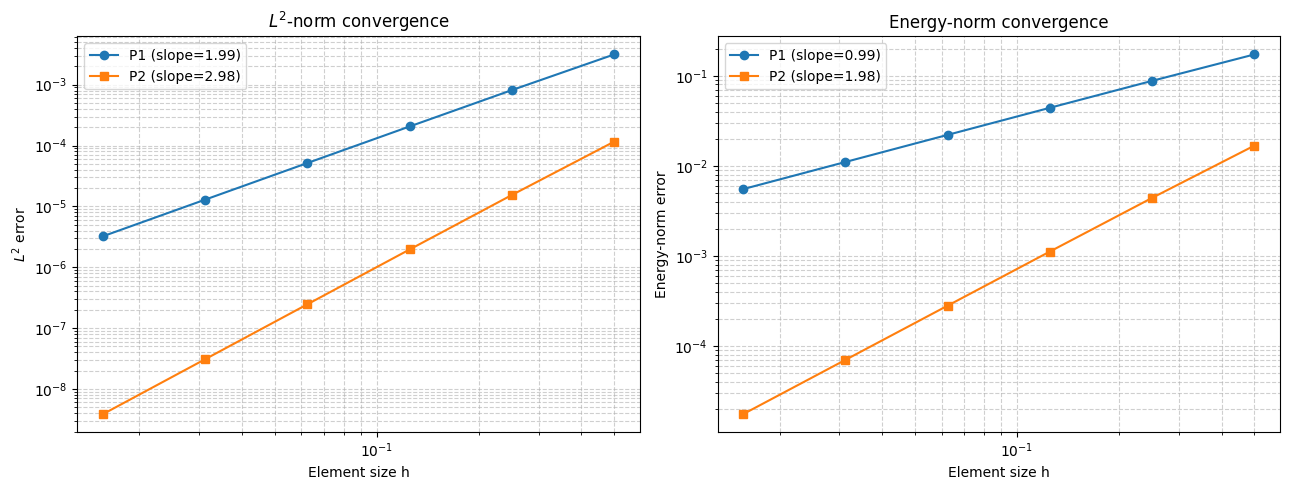

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(results_p1['h'], results_p1['L2'], 'o-', label=f'P1 (slope={slope_p1_L2:.2f})')
axes[0].loglog(results_p2['h'], results_p2['L2'], 's-', label=f'P2 (slope={slope_p2_L2:.2f})')
axes[0].set_xlabel('Element size h')
axes[0].set_ylabel('$L^2$ error')
axes[0].set_title('$L^2$-norm convergence')
axes[0].legend()
axes[0].grid(True, which='both', linestyle='--', alpha=0.6)

axes[1].loglog(results_p1['h'], results_p1['energy'], 'o-', label=f'P1 (slope={slope_p1_E:.2f})')
axes[1].loglog(results_p2['h'], results_p2['energy'], 's-', label=f'P2 (slope={slope_p2_E:.2f})')
axes[1].set_xlabel('Element size h')
axes[1].set_ylabel('Energy-norm error')
axes[1].set_title('Energy-norm convergence')
axes[1].legend()
axes[1].grid(True, which='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 8. 討論

理論預期 P1 的 $L^2$/能量斜率是 2/1,P2 是 3/2。實際擬合出來的斜率通常會非常接近整數值
(通常誤差在 0.02 以內),因為本題的解析解在 $[0,L]$ 上是 $C^\infty$ 光滑函數
(對數函數,分母 $1+x/L$ 在此區間內恆正,不會有奇異點)——這是先驗誤差估計成立的前提之一。

**如果你在自己的專題裡遇到收斂階數明顯低於理論值**,通常代表以下幾種情況之一:
- 解本身不夠光滑(例如材料介面不連續、集中荷重、幾何角點造成應力奇異)
- 網格本身不是均勻加密,或加密方式沒有讓 $h\to0$
- 積分階數不夠,組裝矩陣本身就不精確(本週特別用高於必要階數的高斯積分來排除這個可能性)
- 程式有 bug——這也是為什麼本週先做了手算 P2 vs scikit-fem P2 的交叉驗證,把「程式碼正確」
  這一步驗證完,才敢談「收斂率是否符合理論」

## 9. 討論題(課堂/作業)

1. 把本週的誤差量測函式 `compute_errors` 套用到第 1 週的**常係數**桿件問題上
   (`EA_func` 改回常數)。理論上 P1 元素在節點上的誤差應該還是機器精度,但是**元素內部**
   (非節點位置)呢?畫出 $x\in(0,L)$ 內部連續取樣點的逐點誤差,還會是零嗎?這跟「節點精確性」
   這個詞裡「節點」兩個字的重要性有什麼關係?
2. 如果把邊界條件從「自由端」改成「兩端固定」($u(0)=u(L)=0$),收斂階數的理論預期會改變嗎?
   為什麼?動手改一次驗證。
3. 嘗試把 $EA(x)$ 換成分段常數(左半段 100、右半段 50,在 $x=L/2$ 處不連續)。這個解
   還符合本週理論要求的「解夠光滑」嗎?你預期收斂階數會下降嗎?動手跑一次驗證你的預期
   (提示:這是第 2 週討論題 2 的延伸,現在多了收斂率這個量化工具)。
4. 本週用 `np.polyfit` 對所有 6 個網格密度的點一起擬合斜率。如果只取最粗的兩個網格點
   (`n=2,4`)算斜率,跟取最細的兩個網格點(`n=32,64`)算出來的斜率一樣嗎?哪一個更接近理論值?
   為什麼收斂階數的「漸近」(asymptotic)兩個字很重要?

## 下週預告

第 4 週把視角切回「套件即黑箱」:這次不是驗證答案,而是驗證**收斂行為本身**——
用 scikit-fem 對本週同一個問題重複這次的收斂率實驗,確認套件的 P1/P2 元素收斂階數
與本週手算結果一致,同時討論套件內部網格加密、自適應積分等你看不到的實作細節,
可能在哪裡悄悄影響結果。